# 03 — dN/dS Analysis: Selection pressure on MROH6 copies

## Goal
Test whether MROH6 copies are under purifying selection, neutral drift, or
positive selection using codon-based maximum-likelihood models (PAML codeml),
with the chr7 ancestral locus as the outgroup/reference.

**This analysis is conditional on Step 02 showing elevated mutation rate**
(which it did: 10.8× baseline, p ≈ 0).

## Why dN/dS?

The ratio of nonsynonymous (amino acid-changing) to synonymous (silent)
substitution rates — denoted $\omega = dN/dS$ — is the standard measure of
selection pressure at the molecular level (Yang & Nielsen, 2000, *Mol Biol Evol*
17:32–43):

| $\omega$ value | Interpretation | Biological meaning |
|---|---|---|
| $\omega < 1$ | **Purifying (negative) selection** | Amino acid changes are deleterious and removed — protein function is conserved |
| $\omega = 1$ | **Neutral drift** | Amino acid changes are neither favored nor removed — consistent with pseudogenization |
| $\omega > 1$ | **Positive (diversifying) selection** | Amino acid changes are beneficial and favored — protein is evolving new function |

**Why this matters for MROH6:** Step 02 established that MROH6 copies have
elevated mutation rates consistent with retrotransposition. But elevated
mutation alone doesn't tell us whether these copies are:
- **Functional retrogenes** — expressed proteins under selection ($\omega < 1$)
- **Processed pseudogenes** — non-functional copies evolving neutrally ($\omega
  \approx 1$)
- **Neofunctionalized copies** — copies evolving new functions under positive
  selection ($\omega > 1$)

The dN/dS ratio distinguishes these scenarios, which has profound implications
for whether the MROH6 expansion represents parasitic genome inflation or
adaptive diversification.

## Why PAML codeml?

PAML (Phylogenetic Analysis by Maximum Likelihood; Yang, 2007, *Mol Biol Evol*
24:1586–1591) is the gold standard for codon-based selection analysis because
it:
1. Models codon evolution explicitly (not nucleotide-by-nucleotide), accounting
   for the redundancy of the genetic code
2. Allows heterogeneous $\omega$ across sites via mixture models (some codons
   may be conserved while others are under positive selection)
3. Enables formal hypothesis testing via likelihood ratio tests (LRT) between
   nested models

## Critical caveat (Kryazhimskiy & Plotkin, 2008, *PLoS Genet* 4:e1000304)

dN/dS was developed for **inter-specific** divergence (comparing orthologs
between species). Our MROH6 copies are **paralogs within a single genome** — a
hybrid case between inter-specific divergence and intra-specific polymorphism.
Specific limitations:

- $\omega \approx 1$ is **ambiguous**: could mean neutrality OR strong selection
  + drift (polymorphism hasn't been filtered by long-term selection yet)
- $\omega < 1$ is **ambiguous**: could mean purifying selection OR a recent
  selective sweep
- $\omega >> 1$ at specific sites is the **strongest signal** — harder to
  explain without positive selection
- Global $\omega$ is compared to the bird gene average (~0.15; typical purifying
  selection) to provide context

## PAML models

| Model | $\omega$ structure | What it tests |
|---|---|---|
| **M0** (one-ratio) | Single $\omega$ for all sites and branches | Average selection pressure across entire gene |
| **M1a** (nearly-neutral) | Two classes: $0 < \omega_0 < 1$ and $\omega_1 = 1$ | Baseline: mix of purifying and neutral sites |
| **M2a** (positive selection) | Three classes: $\omega_0 < 1$, $\omega_1 = 1$, $\omega_2 > 1$ | Adds positive selection class (vs M1a) |
| **M7** (beta) | $\omega$ follows a beta distribution on [0, 1] | Flexible neutral baseline |
| **M8** (beta + $\omega_s$) | Beta on [0, 1] + extra class $\omega_s > 1$ | More sensitive positive selection test (vs M7) |

**Likelihood ratio tests (LRT):**
- **M1a vs M2a**: $2\Delta\ell = 2(\ell_{M2a} - \ell_{M1a})$, compared to
  $\chi^2$ with 2 df
- **M7 vs M8**: $2\Delta\ell = 2(\ell_{M8} - \ell_{M7})$, compared to $\chi^2$
  with 2 df

If significant, the alternative model (M2a or M8) fits better, indicating a
proportion of sites with $\omega > 1$.

**Input:** 596 filtered loci from Step 01, subsampled to 20 for computational
tractability

In [4]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO, AlignIO, Phylo
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
from io import StringIO
from pathlib import Path
import subprocess
import os
import re

DATA_PROC = Path('../data/processed')
PAML_DIR = DATA_PROC / 'paml_input'
RESULTS = Path('../results')

PAML_DIR.mkdir(parents=True, exist_ok=True)

sns.set_context('notebook')
sns.set_style('whitegrid')

## 3a. Prepare codon alignment and gene tree

**Why codon alignment?** dN/dS analysis operates on codons (triplets of
nucleotides), not individual bases. Each codon encodes one amino acid, and the
genetic code's redundancy means some nucleotide changes are synonymous (silent,
no amino acid change) while others are nonsynonymous (amino acid-changing). PAML
needs a nucleotide alignment where positions 1, 2, 3 correspond to codon
positions 1, 2, 3 — so the alignment length must be divisible by 3.

**Why the reading frame is known:** The original tBLASTn search used the MROH6
protein as query, so all hits are already in the correct protein reading frame.
We simply need to ensure the alignment is trimmed to a multiple of 3 and that
internal stop codons (which indicate pseudogenization) are masked with NNN
rather than causing PAML to crash.

**Why PAML requires clean input:** PAML codeml is notoriously strict about
input:
- Sequence IDs must be ≤30 characters with no special characters (Yang, 2007)
- Non-ACGT characters must be replaced with N
- Internal stop codons must be masked (they crash codeml)
- Branch lengths must be >0 (zero-length branches cause numerical issues)
- The alignment must be in PHYLIP sequential format

**Why subsample to 20 sequences?** PAML's computational complexity scales
approximately as $O(n^2)$ for the tree optimization and $O(n \times L \times K)$
for the likelihood calculation, where $n$ = sequences, $L$ = alignment length,
$K$ = site classes. With 596 sequences, codeml would require days to weeks.
Subsampling to 20 keeps runtime under 30 minutes per model while retaining
representatives from all chromosome classes.

**Why stratified sampling?** Random subsampling from 596 sequences would yield
~19 microchromosome copies and potentially zero chr7/macro/sex copies (due to
their rarity: 14, 10, and 7 copies respectively). Stratified sampling ensures:
- 1 ancestral copy (always: chr7 locus_787) — the reference point
- 3 chr7 siblings — to assess selection on the parent chromosome
- 4 macrochromosome-derived — to include the divergent macro copies
- 10 microchromosome-derived — proportional to their dominance (94.8%)
- 2 sex chromosome copies — to capture Z/W dynamics

**Why a neighbor-joining (NJ) tree?** PAML requires a guide tree topology but
estimates branch lengths internally. NJ (Saitou & Nei, 1987, *Mol Biol Evol*
4:406–425) is fast, distance-based, and adequate as a guide tree. The exact tree
topology matters less than the alignment quality for site-model tests (M1a vs
M2a, M7 vs M8), because these tests integrate over all branches.

In [5]:
# Load trimmed nucleotide alignment
aln = AlignIO.read(DATA_PROC / 'mroh6_aligned_trimmed.fasta', 'fasta')
print(f"Input alignment: {len(aln)} sequences x {aln.get_alignment_length()} columns")

# For PAML, we need a codon-aware alignment
# The MROH6 protein was used as query for tBLASTn, so hits are in protein reading frame
# We need to ensure the alignment length is divisible by 3

aln_len = aln.get_alignment_length()
trim_to = (aln_len // 3) * 3

codon_records = []
for rec in aln:
    seq = str(rec.seq)[:trim_to]
    # Clean: replace any non-ACGT with N (PAML requirement)
    seq = re.sub(r'[^ACGTacgt-]', 'N', seq)
    # Replace internal stop codons with NNN
    codons = [seq[i:i+3] for i in range(0, len(seq), 3)]
    cleaned_codons = []
    for codon in codons:
        if '-' in codon:
            cleaned_codons.append('---')
        else:
            try:
                aa = Seq(codon).translate()
                if str(aa) == '*':
                    cleaned_codons.append('NNN')  # mask stop codons
                else:
                    cleaned_codons.append(codon)
            except:
                cleaned_codons.append(codon)
    # Sanitize ID for PAML (max 30 chars, no special chars)
    clean_id = re.sub(r'[^A-Za-z0-9_]', '_', rec.id)[:30]
    codon_records.append(SeqRecord(Seq(''.join(cleaned_codons)), id=clean_id, description=''))

print(f"Codon alignment: {len(codon_records)} sequences x {trim_to} columns ({trim_to//3} codons)")

Input alignment: 596 sequences x 501 columns
Codon alignment: 596 sequences x 501 columns (167 codons)


In [6]:
# Subsample for PAML: reduced to 20 to avoid timeout
# Stratified sampling ensures representation from all chromosome classes
MAX_SEQS_PAML = 20

# Load loci metadata for stratified sampling
loci_meta = pd.read_csv(DATA_PROC / 'mroh6_loci_table.csv')
if 'chrom_class' not in loci_meta.columns:
    MACRO_CHROMS = {'1', '1A', '2', '3', '4', '4A', '5', '6', '7', '8'}
    SEX_CHROMS = {'Z', 'W'}
    def classify_chrom(c):
        c = str(c)
        if c == '7': return 'chr7_ancestral'
        elif c in MACRO_CHROMS: return 'macro_derived'
        elif c in SEX_CHROMS: return 'sex_chrom'
        else: return 'micro_derived'
    loci_meta['chrom_class'] = loci_meta['chrom'].astype(str).apply(classify_chrom)

# Map codon record IDs back to chromosome class
id_to_class = {}
for _, row in loci_meta.iterrows():
    clean_id = re.sub(r'[^A-Za-z0-9_]', '_',
        f"locus_{row['locus_id']}_chr{row['chrom']}_{row['start']}_{row['end']}_{row['strand']}")[:30]
    id_to_class[clean_id] = row['chrom_class']

rng = np.random.default_rng(42)

# Always include ancestral chr7 copy
ancestral_recs = [r for r in codon_records if 'chr7_28' in r.id or 'chr7_288' in r.id]
other_recs = [r for r in codon_records if r not in ancestral_recs]

# Stratified sample from chromosome classes
sampled = list(ancestral_recs)
remaining = MAX_SEQS_PAML - len(sampled)

# Get chr7 non-ancestral copies (2-3)
chr7_others = [r for r in other_recs if id_to_class.get(r.id) == 'chr7_ancestral']
macro_recs = [r for r in other_recs if id_to_class.get(r.id) == 'macro_derived']
micro_recs = [r for r in other_recs if id_to_class.get(r.id) == 'micro_derived']
sex_recs = [r for r in other_recs if id_to_class.get(r.id) == 'sex_chrom']

# Allocate: 3 chr7, 4 macro, 10 micro, 2 sex (proportional to counts)
for pool, n_take in [(chr7_others, 3), (macro_recs, 4), (micro_recs, min(10, remaining)), (sex_recs, 2)]:
    if pool:
        take = min(n_take, len(pool))
        idx = rng.choice(len(pool), size=take, replace=False)
        sampled.extend([pool[i] for i in idx])

# Trim to MAX_SEQS_PAML if overshot
codon_records_paml = sampled[:MAX_SEQS_PAML]

print(f"Stratified sample for PAML: {len(codon_records_paml)} sequences")
class_counts = {}
for r in codon_records_paml:
    cls = id_to_class.get(r.id, 'unknown')
    class_counts[cls] = class_counts.get(cls, 0) + 1
for cls, n in sorted(class_counts.items()):
    print(f"  {cls}: {n}")

NotImplementedError: SeqRecord comparison is deliberately not implemented. Explicitly compare the attributes of interest.

In [ ]:
ancestral_ids = {r.id for r in ancestral_recs}  # Create a set of IDs for ancestral records
other_recs = [r for r in codon_records if r.id not in ancestral_ids]

In [ ]:
# Always include ancestral chr7 copy
ancestral_recs = [r for r in codon_records if 'chr7_28' in r.id or 'chr7_288' in r.id]
ancestral_ids = {r.id for r in ancestral_recs}  # Create a set of IDs for ancestral records
other_recs = [r for r in codon_records if r.id not in ancestral_ids]

In [4]:
# Write PAML-format alignment (PHYLIP sequential)
paml_aln_path = PAML_DIR / 'mroh6_codon.phy'
seq_len = len(codon_records_paml[0].seq)

with open(paml_aln_path, 'w') as f:
    f.write(f"  {len(codon_records_paml)}  {seq_len}\n")
    for rec in codon_records_paml:
        f.write(f"{rec.id:<30s}  {str(rec.seq)}\n")

print(f"Wrote PAML alignment: {paml_aln_path}")

Wrote PAML alignment: ../data/processed/paml_input/mroh6_codon.phy


Wrote NJ tree: ../data/processed/paml_input/mroh6_nj.tree


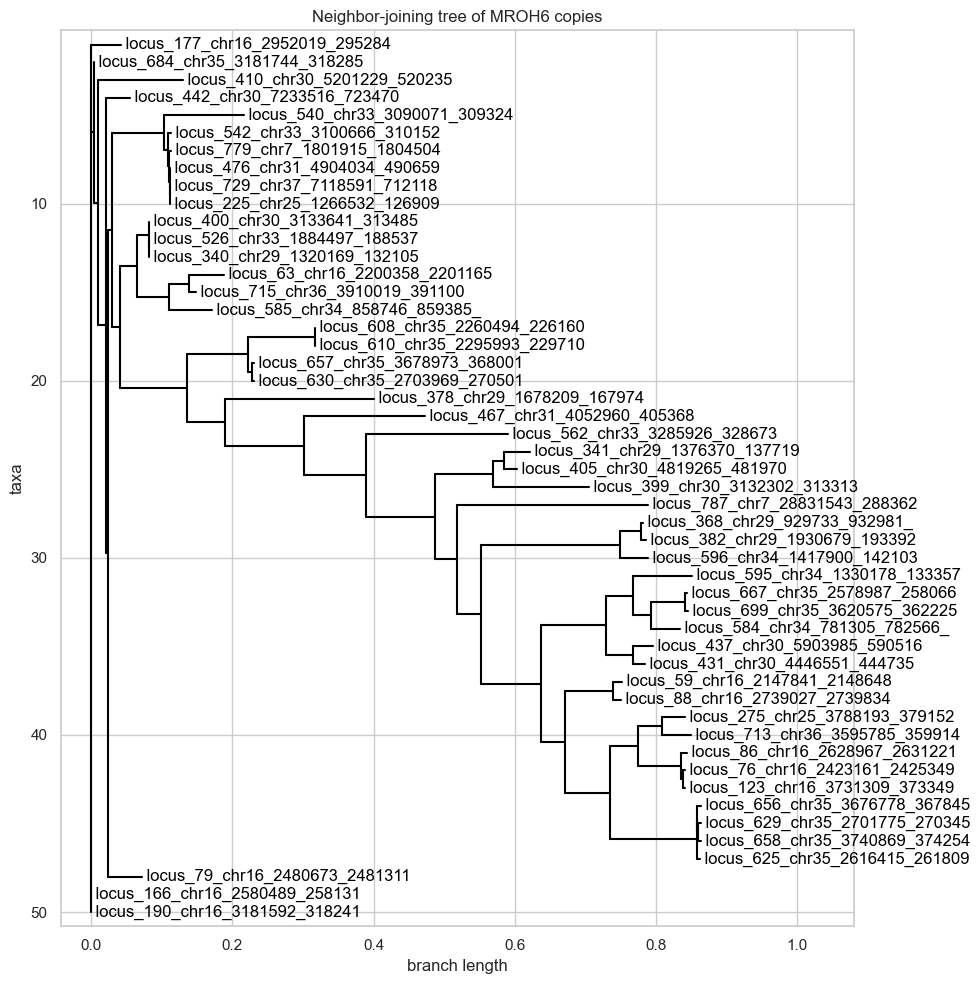

In [5]:
# Build NJ tree
from Bio.Align import MultipleSeqAlignment

paml_aln = MultipleSeqAlignment(codon_records_paml)
calculator = DistanceCalculator('identity')
dm = calculator.get_distance(paml_aln)
constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(dm)

# Strip internal node names (PAML doesn't like them)
for clade in nj_tree.find_clades():
    if not clade.is_terminal():
        clade.name = None
    # Replace zero branch lengths with small value (avoids numerical issues)
    if clade.branch_length is not None and clade.branch_length <= 0:
        clade.branch_length = 1e-6

# Write tree in Newick format
tree_path = PAML_DIR / 'mroh6_nj.tree'
Phylo.write(nj_tree, tree_path, 'newick')
print(f"Wrote NJ tree: {tree_path}")

# Visualize tree
fig, ax = plt.subplots(figsize=(10, max(8, len(codon_records_paml) * 0.2)))
Phylo.draw(nj_tree, axes=ax, do_show=False)
ax.set_title('Neighbor-joining tree of MROH6 copies')
plt.tight_layout()
plt.savefig(RESULTS / 'figures' / 'mroh6_nj_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 3b. Run PAML codeml

**What we are doing:** Running five nested maximum-likelihood models that differ
in how they parameterize $\omega = dN/dS$ across codon sites. By comparing the
log-likelihoods of nested models, we can formally test whether a model with
positive selection ($\omega > 1$) fits the data significantly better than a
model without it.

**How codeml works internally:** For each model, codeml:
1. Reads the codon alignment and guide tree
2. For each codon site, computes the probability of the observed data under the
   model's $\omega$ distribution
3. Optimizes all free parameters (branch lengths, $\kappa$ = Ts/Tv, $\omega$
   class proportions) to maximize the log-likelihood $\ell$
4. Reports the maximum $\ell$, parameter estimates, and per-site posterior
   probabilities

**Key control file parameters:**
- `CodonFreq = 2`: F3×4 codon frequency model — estimates codon frequencies from
  nucleotide composition at each codon position. This is the standard choice
  (Yang, 2007) and avoids the 60 free parameters of `CodonFreq = 3` (F61).
- `cleandata = 1`: Removes alignment columns with gaps or ambiguous characters
  before analysis. This is conservative but avoids artifacts from gap-rich
  regions.
- `kappa = 2`: Starting value for the transition/transversion rate ratio. PAML
  will optimize this, so the starting value just affects convergence speed.
- `omega = 0.4`: Starting value for $\omega$. Again, optimized during ML
  estimation.

**Expected runtime:** With 20 sequences × 167 codons, each model should complete
in 5–30 minutes. M0 is fastest (fewest parameters); M8 is slowest (beta
distribution + extra class).

In [6]:
def write_codeml_ctl(model_name, seqfile, treefile, outfile, **kwargs):
    """Write a PAML codeml control file."""
    defaults = {
        'seqfile': str(seqfile),
        'treefile': str(treefile),
        'outfile': str(outfile),
        'noisy': 0,
        'verbose': 0,
        'runmode': 0,
        'seqtype': 1,
        'CodonFreq': 2,  # F3x4
        'model': 0,
        'NSsites': 0,
        'icode': 0,  # universal code
        'fix_kappa': 0,
        'kappa': 2,
        'fix_omega': 0,
        'omega': 0.4,
        'fix_alpha': 1,
        'alpha': 0,
        'getSE': 0,
        'RateAncestor': 0,
        'cleandata': 1,
    }
    defaults.update(kwargs)
    
    ctl_path = PAML_DIR / f'{model_name}.ctl'
    with open(ctl_path, 'w') as f:
        for key, val in defaults.items():
            f.write(f"      {key} = {val}\n")
    return ctl_path


def parse_codeml_output(outfile):
    """Parse key results from codeml output."""
    results = {}
    with open(outfile) as f:
        text = f.read()
    
    # lnL
    lnl_match = re.search(r'lnL.*?(-\d+\.\d+)', text)
    if lnl_match:
        results['lnL'] = float(lnl_match.group(1))
    
    # omega (dN/dS)
    omega_match = re.search(r'omega \(dN/dS\)\s*=\s*(\d+\.\d+)', text)
    if omega_match:
        results['omega'] = float(omega_match.group(1))
    
    # kappa
    kappa_match = re.search(r'kappa \(ts/tv\)\s*=\s*(\d+\.\d+)', text)
    if kappa_match:
        results['kappa'] = float(kappa_match.group(1))
    
    # np (number of parameters)
    np_match = re.search(r'lnL.*?np:\s*(\d+)', text)
    if np_match:
        results['np'] = int(np_match.group(1))
    
    return results

print("Control file writer and parser ready.")

Control file writer and parser ready.


In [7]:
# Model M0: single omega
ctl_m0 = write_codeml_ctl(
    'M0',
    seqfile=paml_aln_path,
    treefile=tree_path,
    outfile=PAML_DIR / 'M0_out.txt',
    model=0, NSsites=0
)

# Model M1a: nearly neutral (omega classes: 0<ω<1 and ω=1)
ctl_m1a = write_codeml_ctl(
    'M1a',
    seqfile=paml_aln_path,
    treefile=tree_path,
    outfile=PAML_DIR / 'M1a_out.txt',
    model=0, NSsites=1
)

# Model M2a: positive selection (adds ω>1 class)
ctl_m2a = write_codeml_ctl(
    'M2a',
    seqfile=paml_aln_path,
    treefile=tree_path,
    outfile=PAML_DIR / 'M2a_out.txt',
    model=0, NSsites=2
)

# Model M7: beta distribution of omega
ctl_m7 = write_codeml_ctl(
    'M7',
    seqfile=paml_aln_path,
    treefile=tree_path,
    outfile=PAML_DIR / 'M7_out.txt',
    model=0, NSsites=7
)

# Model M8: beta + omega > 1
ctl_m8 = write_codeml_ctl(
    'M8',
    seqfile=paml_aln_path,
    treefile=tree_path,
    outfile=PAML_DIR / 'M8_out.txt',
    model=0, NSsites=8
)

print("Control files written for models: M0, M1a, M2a, M7, M8")

Control files written for models: M0, M1a, M2a, M7, M8


In [ ]:
# Run codeml for each model
# With 20 sequences, each model should complete in minutes rather than hours
models = ['M0', 'M1a', 'M2a', 'M7', 'M8']
results = {}

for model in models:
    ctl_file = PAML_DIR / f'{model}.ctl'
    out_file = PAML_DIR / f'{model}_out.txt'
    
    print(f"Running codeml {model}...", end=' ', flush=True)
    try:
        result = subprocess.run(
            ['codeml', str(ctl_file)],
            capture_output=True, text=True,
            cwd=str(PAML_DIR),
            timeout=1800  # 30 min timeout (should be enough for 20 seqs)
        )
        
        if result.returncode == 0 and out_file.exists():
            results[model] = parse_codeml_output(out_file)
            print(f"done. lnL = {results[model].get('lnL', 'N/A')}")
        else:
            print(f"FAILED (returncode={result.returncode})")
            if result.stderr:
                print(f"  stderr: {result.stderr[:200]}")
            results[model] = {}
    except subprocess.TimeoutExpired:
        print(f"TIMEOUT (30 min)")
        results[model] = {}

print(f"\nCompleted models: {[m for m in models if results.get(m)]}")
print(f"Failed models:    {[m for m in models if not results.get(m)]}")

## 3c. Likelihood ratio tests

**Why LRT?** The models are nested — M1a is a special case of M2a (with the
$\omega > 1$ class constrained to have proportion = 0), and M7 is a special case
of M8. The likelihood ratio test (LRT) compares the fit of two nested models:

$$2\Delta\ell = 2(\ell_{\text{alternative}} - \ell_{\text{null}})$$

Under the null hypothesis (the simpler model is correct), $2\Delta\ell$ follows
a $\chi^2$ distribution with degrees of freedom equal to the difference in free
parameters between models.

**For M1a vs M2a:** M2a adds 2 parameters ($\omega_2$ and its proportion $p_2$),
so df = 2. A significant result (p < 0.05) means there exists a class of sites
with $\omega > 1$ — evidence for positive selection.

**For M7 vs M8:** M8 adds 2 parameters ($\omega_s$ and its proportion $p_s$), so
df = 2. M7 vs M8 is generally considered the more powerful test because M7's
beta distribution provides a more flexible null model than M1a's two discrete
classes.

**Interpretation guidelines:**
- If **both** M1a vs M2a AND M7 vs M8 are significant: strong evidence for
  positive selection
- If **only** M7 vs M8 is significant: moderate evidence (M7/M8 is more
  sensitive)
- If **neither** is significant: no evidence for positive selection at
  individual sites
- A non-significant LRT does NOT mean the gene is evolving neutrally — the
  global $\omega$ from M0 still provides information about average selection
  pressure

In [ ]:
def lrt(null_model, alt_model, results_dict):
    """Perform likelihood ratio test between two nested models."""
    if null_model not in results_dict or alt_model not in results_dict:
        return None, None, None
    lnl_null = results_dict[null_model].get('lnL')
    lnl_alt = results_dict[alt_model].get('lnL')
    np_null = results_dict[null_model].get('np', 0)
    np_alt = results_dict[alt_model].get('np', 0)
    
    if lnl_null is None or lnl_alt is None:
        return None, None, None
    
    from scipy.stats import chi2
    delta = 2 * (lnl_alt - lnl_null)
    df = np_alt - np_null
    if df <= 0:
        df = 2  # default for M1a vs M2a
    p_val = chi2.sf(delta, df)
    return delta, df, p_val

# Test M1a vs M2a (positive selection)
delta_12, df_12, p_12 = lrt('M1a', 'M2a', results)
print("LRT: M1a (nearly neutral) vs M2a (positive selection)")
if delta_12 is not None:
    print(f"  2ΔlnL = {delta_12:.2f}, df = {df_12}, p = {p_12:.4e}")
    print(f"  {'SIGNIFICANT' if p_12 < 0.05 else 'Not significant'} at α=0.05")
else:
    print("  Could not compute (missing model results)")

# Test M7 vs M8
delta_78, df_78, p_78 = lrt('M7', 'M8', results)
print("\nLRT: M7 (beta) vs M8 (beta + ω>1)")
if delta_78 is not None:
    print(f"  2ΔlnL = {delta_78:.2f}, df = {df_78}, p = {p_78:.4e}")
    print(f"  {'SIGNIFICANT' if p_78 < 0.05 else 'Not significant'} at α=0.05")
else:
    print("  Could not compute (missing model results)")

## 3d. Interpretation framework

**How to interpret the M0 global $\omega$:** The M0 model gives a single
$\omega$ for all sites and branches — a rough average. We contextualize it
against known references:

| $\omega$ range | Interpretation | Comparison to bird gene average (~0.15) |
|---|---|---|
| $\omega < 0.3$ | Strong purifying selection — protein function is maintained | Near or below average — gene is functional |
| $0.3 < \omega < 0.8$ | Relaxed constraint — some functional erosion | Above average — may be losing function |
| $0.8 < \omega < 1.2$ | Near-neutral (**CAUTION**: ambiguous per Kryazhimskiy & Plotkin, 2008) | Much above average — likely pseudogenizing |
| $\omega > 1.2$ | Elevated — possible positive selection or very relaxed constraint | Potential neofunctionalization |

**Why compare to bird gene average (~0.15)?** The average $\omega$ across bird
protein-coding genes reflects the typical purifying selection pressure on
functional genes. MROH6 copies with $\omega$ much higher than 0.15 are either
experiencing relaxed constraint (consistent with pseudogenization after
retrotransposition) or positive selection.

**Kryazhimskiy & Plotkin (2008) caveats applied to our case:**

This is not a standard inter-specific comparison. MROH6 copies are paralogs
within a single genome, which creates a hybrid between divergence and
polymorphism. Key implications:

1. **dN/dS ≈ 1 is expected for young pseudogenes** even without positive
   selection, because purifying selection has not yet had time to act
   differentially on synonymous vs. nonsynonymous sites
2. **dN/dS < 1 is expected for functional retrogenes** that have been co-opted
   into new roles — some retrogenes become essential genes (Vinckenbosch et al.,
   2006, *Trends Genet* 22:621–626)
3. **Only dN/dS >> 1 at specific sites** provides compelling evidence for
   adaptive evolution, because this pattern is very difficult to produce by
   drift alone

**References cited in this notebook:**
- Kryazhimskiy & Plotkin (2008) *PLoS Genet* 4:e1000304
- Saitou & Nei (1987) *Mol Biol Evol* 4:406–425
- Vinckenbosch et al. (2006) *Trends Genet* 22:621–626
- Yang (2007) *Mol Biol Evol* 24:1586–1591
- Yang & Nielsen (2000) *Mol Biol Evol* 17:32–43

In [ ]:
# Summary
print("="*60)
print("dN/dS ANALYSIS SUMMARY")
print("="*60)

# M0 global omega
if 'M0' in results and 'omega' in results['M0']:
    omega_m0 = results['M0']['omega']
    print(f"\nGlobal dN/dS (M0): {omega_m0:.4f}")
    if omega_m0 < 0.3:
        print("  → Strong purifying selection")
    elif omega_m0 < 0.8:
        print("  → Moderate purifying selection / relaxed constraint")
    elif omega_m0 < 1.2:
        print("  → Near-neutral (CAUTION: ambiguous intra-specifically per K&P 2008)")
    else:
        print("  → Elevated dN/dS — possible positive selection")

    # Compare to known averages
    # Average dN/dS for bird genes: ~0.1-0.2 (purifying selection)
    bird_avg_dnds = 0.15
    print(f"\n  Bird gene average dN/dS: ~{bird_avg_dnds}")
    print(f"  MROH6 multicopy dN/dS: {omega_m0:.4f}")
    print(f"  Ratio: {omega_m0/bird_avg_dnds:.1f}x the bird average")

# Positive selection tests
print(f"\nPositive selection (M1a vs M2a): p = {p_12:.2e}" if p_12 is not None else "\nM1a vs M2a: not computed")
print(f"Positive selection (M7 vs M8):   p = {p_78:.2e}" if p_78 is not None else "M7 vs M8: not computed")

print("\n--- CAUTION (Kryazhimskiy & Plotkin 2008) ---")
print("These copies are paralogs within a single genome (hybrid case).")
print("dN/dS ≈ 1 could reflect neutrality OR selection + drift.")
print("dN/dS < 1 could reflect purifying selection OR selective sweep.")
print("Only dN/dS >> 1 at specific sites provides strong evidence for positive selection.")

In [ ]:
# Save results table
results_table = []
for model in models:
    row = {'Model': model}
    row.update(results.get(model, {}))
    results_table.append(row)

results_df = pd.DataFrame(results_table)
results_df.to_csv(RESULTS / 'tables' / 'paml_results.csv', index=False)
print("Saved PAML results to tables/paml_results.csv")
print(results_df.to_string(index=False))